# Model Evaluation & Experiments

This notebook contains the code for Section 5 "Experiments" including reading loss and evaluation metrics from the log files and all figures included in the project documentation plus some additional ones.

In [ ]:
# set path to the directory containing all log files
log_dir = "logfiles"

In [48]:
# import modules
import matplotlib.pyplot as plt
import pandas as pd
import os

In [49]:
# read log files into one dictionary
lpf = {}

for file in os.listdir(log_dir):
    filepath = os.path.join(log_dir, file)
    name = file.replace("log_pickle_", "").replace(".txt", "")

    with open(filepath, "r", encoding = "utf-8") as f:
        lines = f.readlines()

        lpf[name] = lines


In [53]:
# get evaluation on test data

def read_metrics(lines_per_file: dict):

    eval_on_test = {}

    for row_name, lines in lines_per_file.items():

        for i in range(len(lines)):
            if "Evaluate on test" in lines[i]:
                metrics = {
                    "mr" : float(lines[i+1].split("   ")[1].split(" ")[1].strip()),
                    "mrr" : float(lines[i+2].split("   ")[1].split(" ")[1].strip()),
                    "hits@1" : float(lines[i+3].split("   ")[1].split(" ")[1].strip()),
                    "hits@3" : float(lines[i+4].split("   ")[1].split(" ")[1].strip()),
                    "hits@10" : float(lines[i+5].split("   ")[1].split(" ")[1].strip()),
                }
                eval_on_test[row_name] = metrics

    return pd.DataFrame(eval_on_test).T

df = read_metrics(lpf)
df

,mr,mrr,hits@1,hits@3,hits@10
3g_00epochs,762.595,0.099275,0.058139,0.134884,0.165116
3g_01epochs,547.337,0.142961,0.106977,0.162791,0.200000
3g_05epochs,540.802,0.138926,0.104651,0.160465,0.188372
3g_10epochs,539.233,0.143588,0.100000,0.167442,0.206977
3g_20epochs,547.644,0.152655,0.120930,0.167442,0.204651
4g_00epochs,621.698,0.111338,0.062791,0.151163,0.172093
4g_01epochs,540.400,0.147006,0.113953,0.162791,0.200000
4g_05epochs,525.898,0.143489,0.111628,0.160465,0.183721
4g_10epochs,540.837,0.148965,0.123256,0.162791,0.197674
4g_20epochs,546.230,0.156768,0.132558,0.165116,0.202326


In [54]:
# get model instance with best performance averaged over all metrics except mr
df_wo_mr = df.drop("mr", axis = 1)
df_wo_mr["overall"] = df_wo_mr.sum(axis = 1)/4
df_wo_mr

,mrr,hits@1,hits@3,hits@10,overall
3g_00epochs,0.099275,0.058139,0.134884,0.165116,0.114354
3g_01epochs,0.142961,0.106977,0.162791,0.200000,0.153182
3g_05epochs,0.138926,0.104651,0.160465,0.188372,0.148103
3g_10epochs,0.143588,0.100000,0.167442,0.206977,0.154502
3g_20epochs,0.152655,0.120930,0.167442,0.204651,0.161420
4g_00epochs,0.111338,0.062791,0.151163,0.172093,0.124346
4g_01epochs,0.147006,0.113953,0.162791,0.200000,0.155938
4g_05epochs,0.143489,0.111628,0.160465,0.183721,0.149826
4g_10epochs,0.148965,0.123256,0.162791,0.197674,0.158171
4g_20epochs,0.156768,0.132558,0.165116,0.202326,0.164192


In [55]:
# get LaTeX tabular from above Dataframe
print(df.to_latex(index = True,
                float_format = "{:.4f}".format))

\begin{tabular}{lrrrrr}
\toprule
 & mr & mrr & hits@1 & hits@3 & hits@10 \\
\midrule
3g_00epochs & 762.5950 & 0.0993 & 0.0581 & 0.1349 & 0.1651 \\
3g_01epochs & 547.3370 & 0.1430 & 0.1070 & 0.1628 & 0.2000 \\
3g_05epochs & 540.8020 & 0.1389 & 0.1047 & 0.1605 & 0.1884 \\
3g_10epochs & 539.2330 & 0.1436 & 0.1000 & 0.1674 & 0.2070 \\
3g_20epochs & 547.6440 & 0.1527 & 0.1209 & 0.1674 & 0.2047 \\
4g_00epochs & 621.6980 & 0.1113 & 0.0628 & 0.1512 & 0.1721 \\
4g_01epochs & 540.4000 & 0.1470 & 0.1140 & 0.1628 & 0.2000 \\
4g_05epochs & 525.8980 & 0.1435 & 0.1116 & 0.1605 & 0.1837 \\
4g_10epochs & 540.8370 & 0.1490 & 0.1233 & 0.1628 & 0.1977 \\
4g_20epochs & 546.2300 & 0.1568 & 0.1326 & 0.1651 & 0.2023 \\
50g_00epochs & 640.9090 & 0.0884 & 0.0558 & 0.1093 & 0.1419 \\
50g_01epochs & 556.6330 & 0.1512 & 0.1209 & 0.1674 & 0.2000 \\
50g_05epochs & 535.2740 & 0.1474 & 0.1163 & 0.1558 & 0.1977 \\
50g_10epochs & 541.6120 & 0.1467 & 0.1116 & 0.1558 & 0.2023 \\
50g_20epochs & 561.4720 & 0.1467 & 0.1140 &

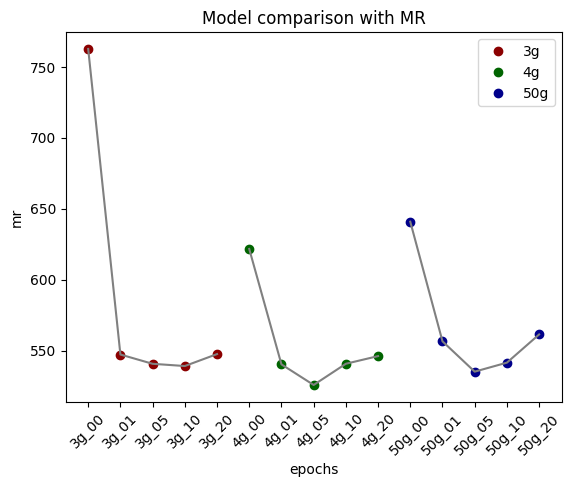

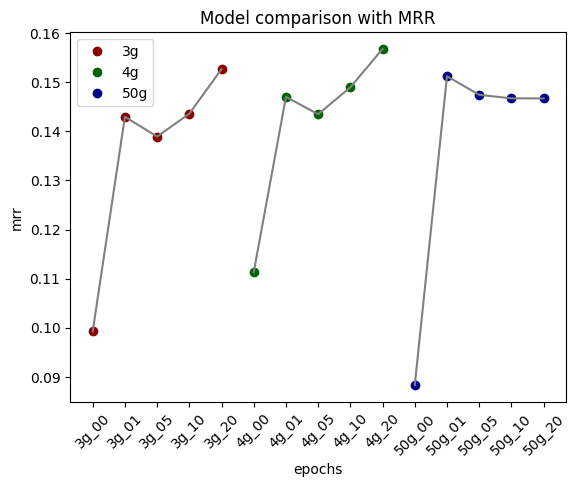

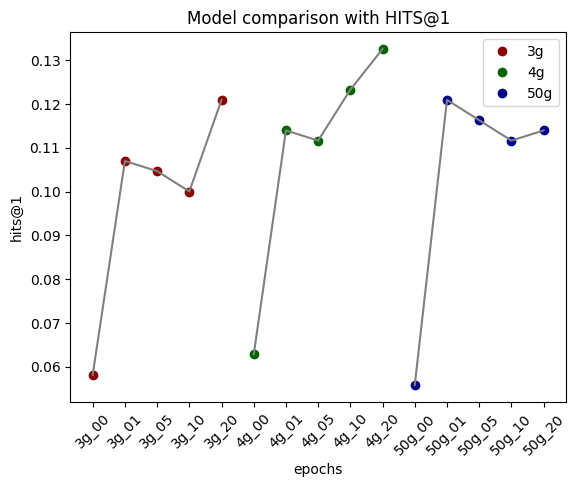

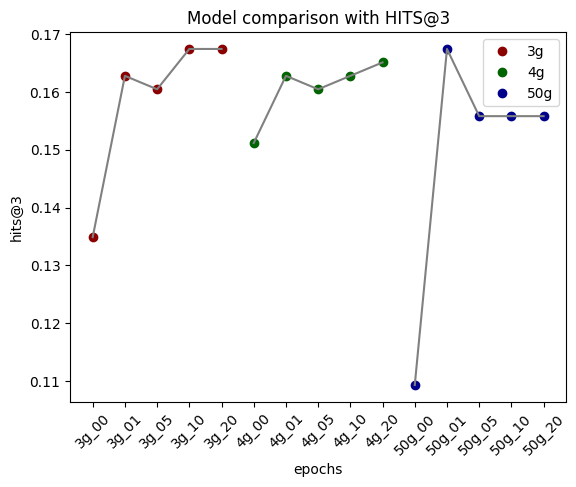

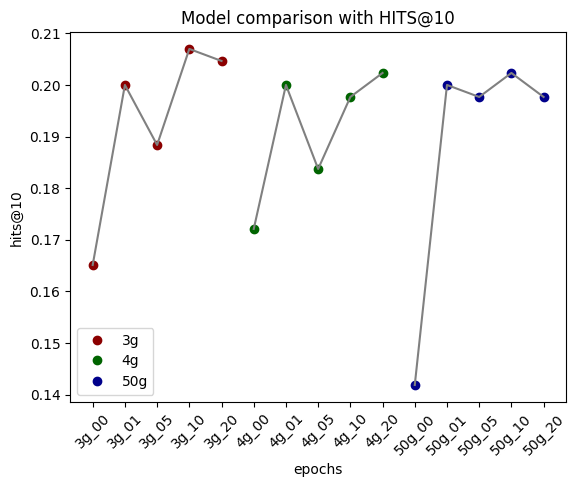

In [56]:
def plot_per_metric(df, col_name):

    # get respective column from dataframe
    vals = df[col_name]
    
    # plot datapoints
    fig, ax = plt.subplots()
    xlabels = []
    for idx, val in zip(vals.index, vals):
        if (name := "3g") in idx:
            colour = "darkred"
        elif (name := "4g") in idx:
            colour = "darkgreen"
        elif (name := "50g") in idx:
            colour = "darkblue"

        xlabel = idx.replace("epochs", "")
        xlabels.append(xlabel)

        if "00" in xlabel:
            ax.plot(xlabel, val, "o", color = colour, label = name)
        else:
            ax.plot(xlabel, val, "o", color = colour)

    # plot curves over datapoints
    ax.plot(xlabels[0:5], vals[0:5], color = "grey")
    ax.plot(xlabels[5:10], vals[5:10], color = "grey")
    ax.plot(xlabels[10:], vals[10:], color = "grey")

    # configure plot
    ax.set_title(f"Model comparison with {col_name.upper()}")
    ax.tick_params(axis='x', labelrotation=45,)
    ax.set_ylabel(col_name)
    ax.set_xlabel("epochs")
    ax.legend()


plot_per_metric(df, "mr")
plot_per_metric(df, "mrr")
plot_per_metric(df, "hits@1")
plot_per_metric(df, "hits@3")
plot_per_metric(df, "hits@10")


In [57]:
# get average binary cross entropy loss during finetuning

def get_finetuning_loss(lines_per_file: dict):

    finetuning_loss = {}

    for row_name, lines in lines_per_file.items():
        epoch = -1
        loss_per_model = {}

        for l in lines:
            if "Epoch" and "end" in l:
                epoch = int(l.split("   ")[1].split(" ")[1])
            if "average binary cross entropy" in l:
                loss = float(l.split("   ")[1].split(": ")[1].strip())
                loss_per_model[epoch] = loss

        finetuning_loss[row_name] = loss_per_model

    return finetuning_loss

ftl = get_finetuning_loss(lpf)
ftl

{'3g_00epochs': {},
 '3g_01epochs': {0: 0.634322},
 '3g_05epochs': {0: 0.634105,
  1: 0.61953,
  2: 0.616241,
  3: 0.618203,
  4: 0.614952},
 '3g_10epochs': {0: 0.634304,
  1: 0.619464,
  2: 0.61694,
  3: 0.619276,
  4: 0.615303,
  5: 0.616841,
  6: 0.61632,
  7: 0.616433,
  8: 0.613466,
  9: 0.617372},
 '3g_20epochs': {0: 0.634159,
  1: 0.620533,
  2: 0.61619,
  3: 0.618813,
  4: 0.614511,
  5: 0.616587,
  6: 0.616322,
  7: 0.616264,
  8: 0.612992,
  9: 0.618455,
  10: 0.614555,
  11: 0.617186,
  12: 0.61568,
  13: 0.613256,
  14: 0.613049,
  15: 0.61492,
  16: 0.614219,
  17: 0.613329,
  18: 0.614139,
  19: 0.611271},
 '4g_00epochs': {},
 '4g_01epochs': {0: 0.627936},
 '4g_05epochs': {0: 0.627658,
  1: 0.619565,
  2: 0.616382,
  3: 0.618975,
  4: 0.614998},
 '4g_10epochs': {0: 0.627933,
  1: 0.619671,
  2: 0.616097,
  3: 0.61969,
  4: 0.614168,
  5: 0.617084,
  6: 0.61522,
  7: 0.616386,
  8: 0.613985,
  9: 0.617969},
 '4g_20epochs': {0: 0.628061,
  1: 0.620133,
  2: 0.615981,
  3: 0

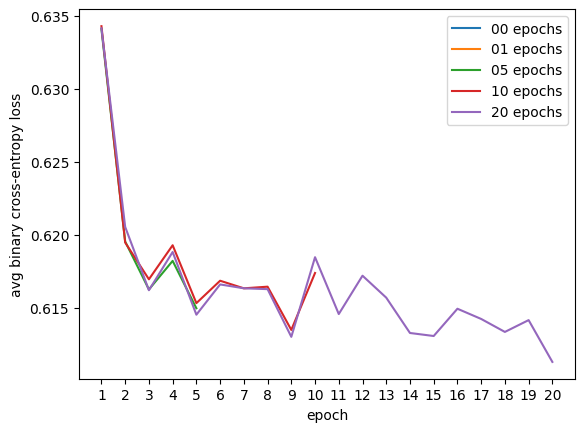

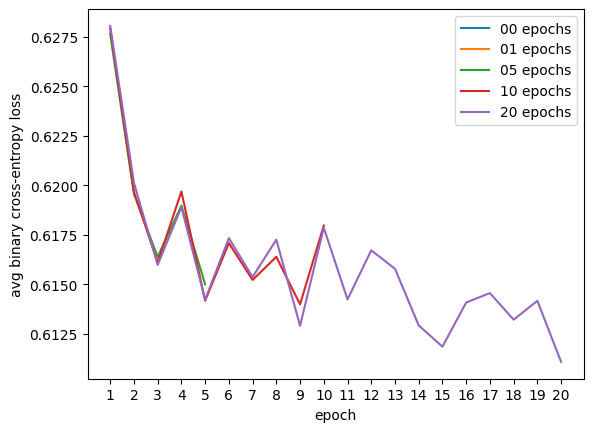

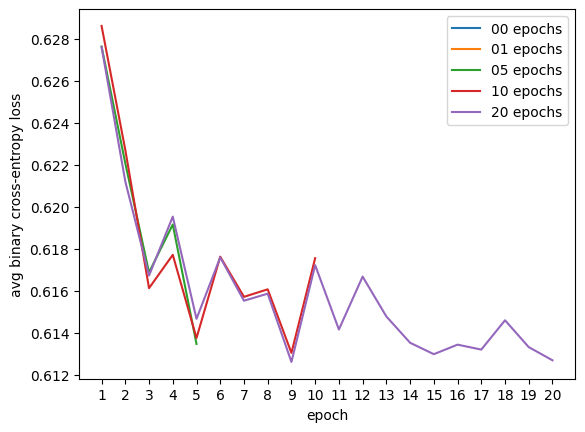

In [58]:
# plot finetuning loss per model size

def plot_finetuning_loss(finetuning_loss, modelsize):

    fig, ax = plt.subplots()
    ax.set_xticks(range(21))
    ax.set_xlabel("epoch")
    ax.set_ylabel("avg binary cross-entropy loss")
    #ax.set_title(f"Loss during fine-tuning for {modelsize} model.")

    for name, loss_dict in finetuning_loss.items():
        if modelsize in name:
            ax.plot([i + 1 for i in loss_dict.keys()], loss_dict.values(), label = name.split("_")[1].replace("epochs", " epochs"))

    ax.legend()


plot_finetuning_loss(ftl, "3g")
plot_finetuning_loss(ftl, "4g")
plot_finetuning_loss(ftl, "50g")

In [59]:
# get metrics on validation data during fine-tuning

def get_validation_metrics(lines_per_file, model):
    

    eval_on_valid = {}

    for row_name, lines in lines_per_file.items():

        if row_name == model:
            epoch = -1
            eval_on_valid = {}

            for i in range(len(lines)):

                l = lines[i]

                if "Load checkpoint" in l:
                    break

                if "Epoch" and "end" in l:
                    epoch = int(l.split("   ")[1].split(" ")[1])

                if "Evaluate on valid" in l:
                    metrics = {
                        "mr" : float(lines[i+1].split("   ")[1].split(" ")[1].strip()),
                        "mrr" : float(lines[i+2].split("   ")[1].split(" ")[1].strip()),
                        "hits@1" : float(lines[i+3].split("   ")[1].split(" ")[1].strip()),
                        "hits@3" : float(lines[i+4].split("   ")[1].split(" ")[1].strip()),
                        "hits@10" : float(lines[i+5].split("   ")[1].split(" ")[1].strip()),
                    }
                    eval_on_valid[epoch] = metrics

                

        df = pd.DataFrame(eval_on_valid).T

    return df.drop("mr", axis = 1), df["mr"]


df_valid, df_mr = get_validation_metrics(lpf, "4g_20epochs")
df_valid


,mrr,hits@1,hits@3,hits@10
1,0.156203,0.130233,0.167442,0.200000
3,0.160495,0.139535,0.169767,0.197674
5,0.160218,0.137209,0.174419,0.193023
7,0.149362,0.127907,0.151163,0.190698
9,0.155164,0.130233,0.167442,0.195349
11,0.169033,0.148837,0.174419,0.200000
13,0.155015,0.125581,0.172093,0.195349
15,0.160601,0.132558,0.174419,0.197674
17,0.156529,0.127907,0.169767,0.197674
19,0.155059,0.132558,0.160465,0.197674


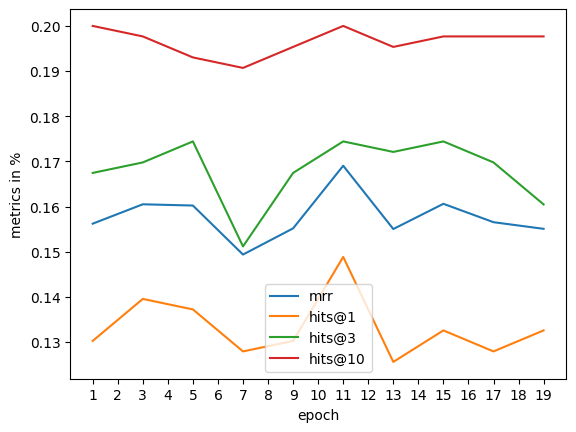

In [60]:
# plot metrics on validation data during fine-tuning

def plot_validation_metrics(df: pd.DataFrame, modelname):

    fig, ax = plt.subplots()
    ax.set_xticks(range(21))
    ax.set_xlabel("epoch")
    ax.set_ylabel("metrics in %")
    #ax.set_title(f"Metrics on validation data during finetuning for {modelname}")

    for metric in df.columns:
        print()
        ax.plot(df[metric], label = metric)

    ax.legend()


plot_validation_metrics(df_valid, "4g_20epochs")

In [61]:
# plot number of relations vs. ULTRA performance

datasets_transductive = "transductive_datasets_relations.tsv"
df_transductive = pd.read_csv(datasets_transductive, sep = "\t", header = 0, index_col = 0)
df_transductive.sort_values(by = "Rels", axis = 0, inplace = True)
df_transductive.drop("AristoV4", axis = 0, inplace = True)
df_transductive

,Entities,Rels,MRR,Hits@10
Dataset,,,,
Hetionet,45158,24,0.257,0.379
ConceptNet100k,78334,34,0.082,0.162
YAGO310,123182,37,0.451,0.615
CoDEx Small,2034,42,0.472,0.667
CoDEx Large,77951,69,0.338,0.469
WDSinger,10282,135,0.382,0.498
NELL23k,22925,200,0.239,0.408
NELL995,74536,200,0.406,0.543
FB15k237_10,11512,237,0.248,0.398


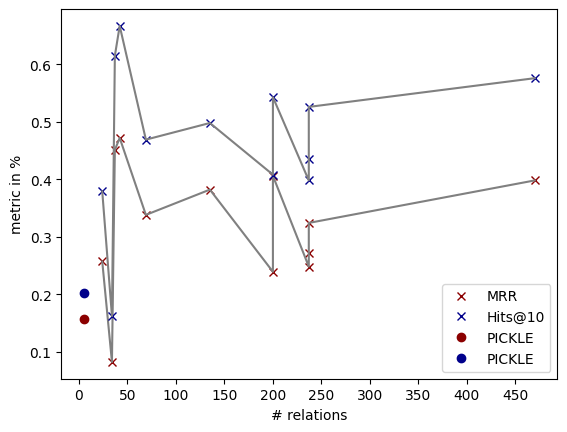

In [62]:
def plot_performance_vs_numrel(dft):

    fig, ax = plt.subplots()
    ax.set_xticks(range(0, 500, 50))
    ax.set_xlabel("# relations")
    ax.set_ylabel("metric in %")
    #ax.set_title("Number of relations in transductive dataset vs. ULTRA performance")

    ax.plot(df_transductive["Rels"], df_transductive["MRR"], "x", color = "darkred", label = "MRR")
    ax.plot(df_transductive["Rels"], df_transductive["MRR"], color = "grey")

    ax.plot(df_transductive["Rels"], df_transductive["Hits@10"], "x", color = "darkblue", label = "Hits@10")
    ax.plot(df_transductive["Rels"], df_transductive["Hits@10"], color = "grey")

    # add MRR & Hits@10 of highest performing PICKLE model (4g_20epochs)
    ax.plot(5, df["mrr"]["4g_20epochs"], "o", color = "darkred", label = "PICKLE")
    ax.plot(5, df["hits@10"]["4g_20epochs"], "o", color = "darkblue", label = "PICKLE")
    ax.legend()

plot_performance_vs_numrel(df_transductive)